# End-to-End Benchmark: Virtual Zarr vs Original NetCDF on S3

This notebook benchmarks timeseries extraction for **NLDAS-3 Rainf** from:

- **Virtual Zarr** via Icechunk
- **Original NetCDF files on S3**

It measures:

1. **Access time**  
   Time to discover or initialize access to the dataset

2. **Open time**  
   Time to open the dataset with xarray and subset the benchmark time range

3. **Selection time**  
   Time to select nearest-neighbor point(s)

4. **Load time**  
   Time to load the selected data into memory

5. **End-to-end time**  
   Access + open + selection + load

## Benchmark setup
- Benchmark cases: **1 point** and **5 points**
- Repeats: **1**
- Virtual Zarr time subset: configurable independently
- Original NetCDF time subset: configurable independently

**Author:** Siddharth Chaudhary


In [25]:
import time
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
from IPython.display import display, Markdown

import icechunk
import s3fs

pd.set_option("display.max_columns", None)


## 1. Benchmark configuration

In [26]:
benchmark_cases = {
    "1 point": {
        "lon": [-74.0060],
        "lat": [40.7128],
    },
    "5 points": {
        "lon": [-74.0060, -58.3816, 139.6917, 151.2093, 37.6173],
        "lat": [40.7128, -34.6037, 35.6895, -33.8688, 55.7558],
    },
}

variable_name = "Rainf"
repeats = 1

# Set these independently
vz_start = "2019-12-01"
vz_end   = "2019-12-31"

nc_start = "2019-12-01"
nc_end   = "2019-12-31"

print("Virtual Zarr period:", vz_start, "to", vz_end)
print("Original NetCDF period:", nc_start, "to", nc_end)


Virtual Zarr period: 2019-12-01 to 2019-12-31
Original NetCDF period: 2019-12-01 to 2019-12-31


## 2. Helper functions

In [27]:
def build_month_strings(start_date, end_date):
    months = pd.period_range(
        start=pd.Period(start_date, freq="M"),
        end=pd.Period(end_date, freq="M"),
        freq="M"
    )
    return [p.strftime("%Y%m") for p in months]


def list_nldas_netcdf_files_s3(start_date, end_date,
                               bucket="nasa-waterinsight",
                               prefix="NLDAS3/forcing/daily"):
    """
    List only the NetCDF files whose dates fall inside the requested range.
    This avoids opening unnecessary files from the whole month.
    """
    fs = s3fs.S3FileSystem(anon=True)

    start = dt.datetime.strptime(start_date, "%Y-%m-%d")
    end   = dt.datetime.strptime(end_date, "%Y-%m-%d")

    months = build_month_strings(start_date, end_date)

    files = []
    for month in months:
        pattern = f"{bucket}/{prefix}/{month}/NLDAS_FOR0010_D.A*.030.beta.nc"
        matches = fs.glob(pattern)

        for m in matches:
            fname = m.split("/")[-1]
            date_str = fname.split(".A")[1][:8]
            file_date = dt.datetime.strptime(date_str, "%Y%m%d")

            if start <= file_date <= end:
                files.append(f"s3://{m}")

    files = sorted(files)

    if not files:
        raise FileNotFoundError("No NetCDF files found for the requested date range.")

    return files


def open_virtual_zarr_with_timing(start_date, end_date):
    t0 = time.perf_counter()

    storage = icechunk.s3_storage(
        bucket="nasa-waterinsight",
        prefix=f"virtual-zarr-store/NLDAS-3-icechunk",
        anonymous=True,
    )

    chunk_url = "s3://nasa-waterinsight/NLDAS3/forcing/daily/"
    virtual_credentials = icechunk.containers_credentials({
        chunk_url: icechunk.s3_anonymous_credentials()
    })

    repo = icechunk.Repository.open(
        storage=storage,
        authorize_virtual_chunk_access=virtual_credentials,
    )

    session = repo.readonly_session("main")
    store = session.store
    t1 = time.perf_counter()

    ds_vz = xr.open_zarr(store, consolidated=False)
    ds_vz = ds_vz.sel(time=slice(start_date, end_date))
    t2 = time.perf_counter()

    timing = {
        "source": "Virtual Zarr",
        "access_time_sec": t1 - t0,
        "open_time_sec": t2 - t1,
        "open_total_time_sec": t2 - t0,
        "n_files": np.nan,
    }

    return ds_vz, timing


def open_original_netcdf_s3_with_timing(start_date, end_date):
    t0 = time.perf_counter()
    files = list_nldas_netcdf_files_s3(start_date, end_date)
    t1 = time.perf_counter()

    ds_nc = xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=False,
        engine="h5netcdf",
        chunks={},
    )
    ds_nc = ds_nc.sel(time=slice(start_date, end_date))
    t2 = time.perf_counter()

    timing = {
        "source": "Original NetCDF",
        "access_time_sec": t1 - t0,
        "open_time_sec": t2 - t1,
        "open_total_time_sec": t2 - t0,
        "n_files": len(files),
    }

    return ds_nc, files, timing


def benchmark_timeseries(ds, lons, lats, var="Rainf", repeats=1):
    results = []
    loaded = None

    selection = {
        "lon": xr.DataArray(lons, dims=["points"]),
        "lat": xr.DataArray(lats, dims=["points"]),
    }

    for run in range(repeats):
        t0 = time.perf_counter()
        subset = ds[var].sel(**selection, method="nearest")
        t1 = time.perf_counter()

        with ProgressBar():
            loaded = subset.load()
        t2 = time.perf_counter()

        results.append({
            "run": run + 1,
            "n_points": len(lons),
            "select_time_sec": t1 - t0,
            "load_time_sec": t2 - t1,
            "query_total_time_sec": t2 - t0,
            "n_time_steps": loaded.sizes.get("time", np.nan),
        })

    return pd.DataFrame(results), loaded


def benchmark_cases_for_source(ds, benchmark_cases, source_name, open_timing, var="Rainf", repeats=1):
    all_results = []
    loaded_outputs = {}

    for case_name, coords in benchmark_cases.items():
        print(f"Running {source_name} benchmark for: {case_name}")

        result_df, loaded = benchmark_timeseries(
            ds=ds,
            lons=coords["lon"],
            lats=coords["lat"],
            var=var,
            repeats=repeats,
        )

        result_df["case"] = case_name
        result_df["source"] = source_name
        result_df["access_time_sec"] = open_timing["access_time_sec"]
        result_df["open_time_sec"] = open_timing["open_time_sec"]
        result_df["open_total_time_sec"] = open_timing["open_total_time_sec"]
        result_df["end_to_end_time_sec"] = (
            result_df["open_total_time_sec"] + result_df["query_total_time_sec"]
        )
        result_df["n_files"] = open_timing.get("n_files", np.nan)

        all_results.append(result_df)
        loaded_outputs[(source_name, case_name)] = loaded

    benchmark_df = pd.concat(all_results, ignore_index=True)
    return benchmark_df, loaded_outputs


def summarize_comparison(comparison_df):
    return (
        comparison_df
        .groupby(["source", "case", "n_points"], as_index=False)
        .agg(
            n_files=("n_files", "first"),
            access_time_sec=("access_time_sec", "first"),
            open_time_sec=("open_time_sec", "first"),
            open_total_time_sec=("open_total_time_sec", "first"),
            mean_select_time_sec=("select_time_sec", "mean"),
            mean_load_time_sec=("load_time_sec", "mean"),
            mean_query_time_sec=("query_total_time_sec", "mean"),
            mean_end_to_end_time_sec=("end_to_end_time_sec", "mean"),
        )
    )


## 3. Open Virtual Zarr and Original NetCDF

In [28]:
# Virtual Zarr
ds_vz, vz_timing = open_virtual_zarr_with_timing(vz_start, vz_end)

print("Virtual Zarr timing:")
display(pd.DataFrame([vz_timing]))


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


Virtual Zarr timing:


,source,access_time_sec,open_time_sec,open_total_time_sec,n_files
0,Virtual Zarr,0.092224,1.832866,1.92509,NaN


In [29]:
# Original NetCDF on S3
ds_nc, netcdf_files, nc_timing = open_original_netcdf_s3_with_timing(
    nc_start,
    nc_end
)

print("Original NetCDF timing:")
display(pd.DataFrame([nc_timing]))

print("NetCDF files used:")
for f in netcdf_files:
    print(f)


Original NetCDF timing:


,source,access_time_sec,open_time_sec,open_total_time_sec,n_files
0,Original NetCDF,0.001421,762.71806,762.719481,31


NetCDF files used:
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191201.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191202.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191203.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191204.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191205.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191206.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191207.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191208.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191209.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191210.030.beta.nc
s3://nasa-waterinsight/NLDAS3/forcing/daily/201912/NLDAS_FOR0010_D.A20191211.030.beta.nc
s3

## 4. Run the end-to-end benchmark

In [30]:
benchmark_vz_df, loaded_outputs_vz = benchmark_cases_for_source(
    ds=ds_vz,
    benchmark_cases=benchmark_cases,
    source_name="Virtual Zarr",
    open_timing=vz_timing,
    var=variable_name,
    repeats=repeats,
)

benchmark_nc_df, loaded_outputs_nc = benchmark_cases_for_source(
    ds=ds_nc,
    benchmark_cases=benchmark_cases,
    source_name="Original NetCDF",
    open_timing=nc_timing,
    var=variable_name,
    repeats=repeats,
)

comparison_df = pd.concat([benchmark_vz_df, benchmark_nc_df], ignore_index=True)

display(Markdown("### Combined per-run comparison"))
display(comparison_df)


Running Virtual Zarr benchmark for: 1 point
[########################################] | 100% Completed | 1.31 ss
Running Virtual Zarr benchmark for: 5 points
[########################################] | 100% Completed | 1.11 sms
Running Original NetCDF benchmark for: 1 point
[########################################] | 100% Completed | 42.61 s
Running Original NetCDF benchmark for: 5 points
[########################################] | 100% Completed | 60.13 s


### Combined per-run comparison

,run,n_points,select_time_sec,load_time_sec,query_total_time_sec,n_time_steps,case,source,access_time_sec,open_time_sec,open_total_time_sec,end_to_end_time_sec,n_files
0,1,1,0.004684,2.181842,2.186526,31,1 point,Virtual Zarr,0.092224,1.832866,1.925090,4.111616,NaN
1,1,5,0.005035,1.986769,1.991804,31,5 points,Virtual Zarr,0.092224,1.832866,1.925090,3.916894,NaN
2,1,1,0.003629,42.627233,42.630862,30,1 point,Original NetCDF,0.001421,762.718060,762.719481,805.350343,31.0
3,1,5,0.004588,60.155764,60.160353,30,5 points,Original NetCDF,0.001421,762.718060,762.719481,822.879834,31.0


In [31]:
comparison_summary = summarize_comparison(comparison_df)

display(Markdown("### Summary comparison"))
display(comparison_summary)


### Summary comparison

,source,case,n_points,n_files,access_time_sec,open_time_sec,open_total_time_sec,mean_select_time_sec,mean_load_time_sec,mean_query_time_sec,mean_end_to_end_time_sec
0,Original NetCDF,1 point,1,31.0,0.001421,762.718060,762.719481,0.003629,42.627233,42.630862,805.350343
1,Original NetCDF,5 points,5,31.0,0.001421,762.718060,762.719481,0.004588,60.155764,60.160353,822.879834
2,Virtual Zarr,1 point,1,NaN,0.092224,1.832866,1.925090,0.004684,2.181842,2.186526,4.111616
3,Virtual Zarr,5 points,5,NaN,0.092224,1.832866,1.925090,0.005035,1.986769,1.991804,3.916894


## 5. Benchmark plots

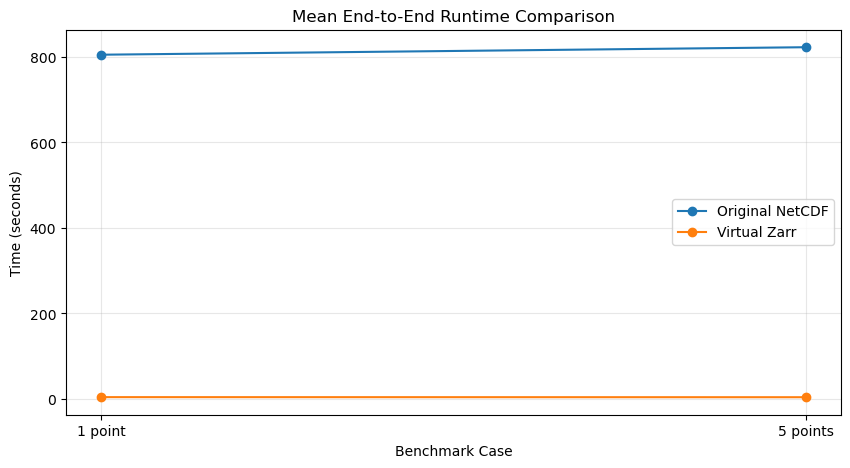

In [32]:
# Mean end-to-end runtime comparison
plt.figure(figsize=(10, 5))
for source_name in comparison_summary["source"].unique():
    sub = comparison_summary[comparison_summary["source"] == source_name]
    plt.plot(sub["case"], sub["mean_end_to_end_time_sec"], marker="o", label=source_name)

plt.title("Mean End-to-End Runtime Comparison")
plt.xlabel("Benchmark Case")
plt.ylabel("Time (seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


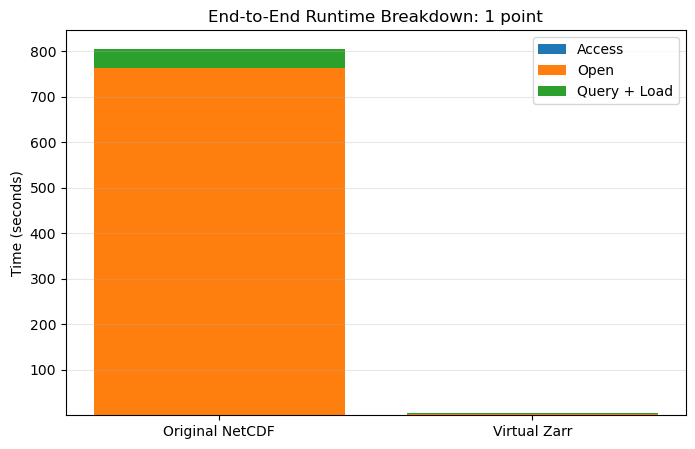

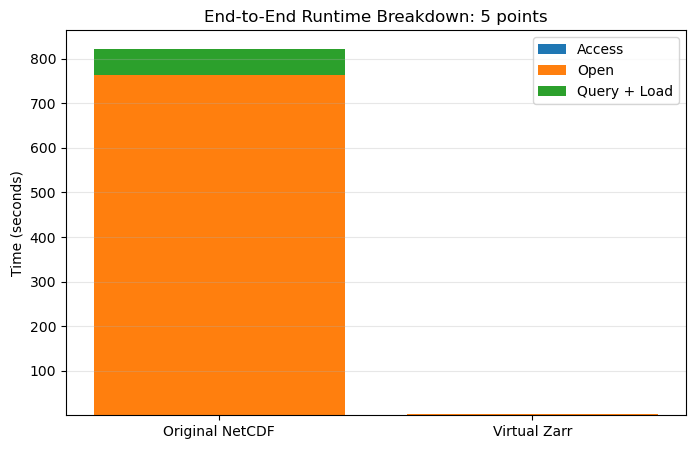

In [33]:
# Runtime breakdown by case
for case_name in comparison_summary["case"].unique():
    sub = comparison_summary[comparison_summary["case"] == case_name].copy()

    plt.figure(figsize=(8, 5))
    plt.bar(sub["source"], sub["access_time_sec"], label="Access")
    plt.bar(
        sub["source"],
        sub["open_time_sec"],
        bottom=sub["access_time_sec"],
        label="Open"
    )
    plt.bar(
        sub["source"],
        sub["mean_query_time_sec"],
        bottom=sub["access_time_sec"] + sub["open_time_sec"],
        label="Query + Load"
    )

    plt.title(f"End-to-End Runtime Breakdown: {case_name}")
    plt.ylabel("Time (seconds)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.show()


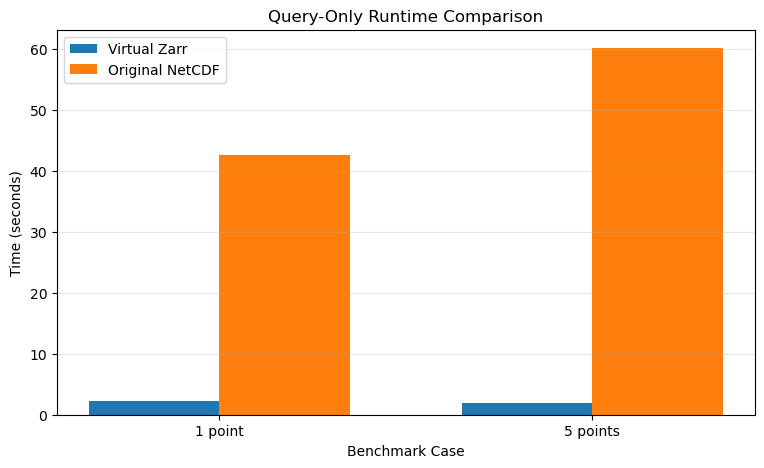

In [34]:
# Query-only runtime comparison
plt.figure(figsize=(9, 5))

cases = list(comparison_summary["case"].unique())
x = np.arange(len(cases))
width = 0.35

vz_vals = [
    comparison_summary[
        (comparison_summary["source"] == "Virtual Zarr") &
        (comparison_summary["case"] == c)
    ]["mean_query_time_sec"].iloc[0]
    for c in cases
]
nc_vals = [
    comparison_summary[
        (comparison_summary["source"] == "Original NetCDF") &
        (comparison_summary["case"] == c)
    ]["mean_query_time_sec"].iloc[0]
    for c in cases
]

plt.bar(x - width/2, vz_vals, width, label="Virtual Zarr")
plt.bar(x + width/2, nc_vals, width, label="Original NetCDF")

plt.xticks(x, cases)
plt.title("Query-Only Runtime Comparison")
plt.xlabel("Benchmark Case")
plt.ylabel("Time (seconds)")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()


## 6. Histograms of extracted values

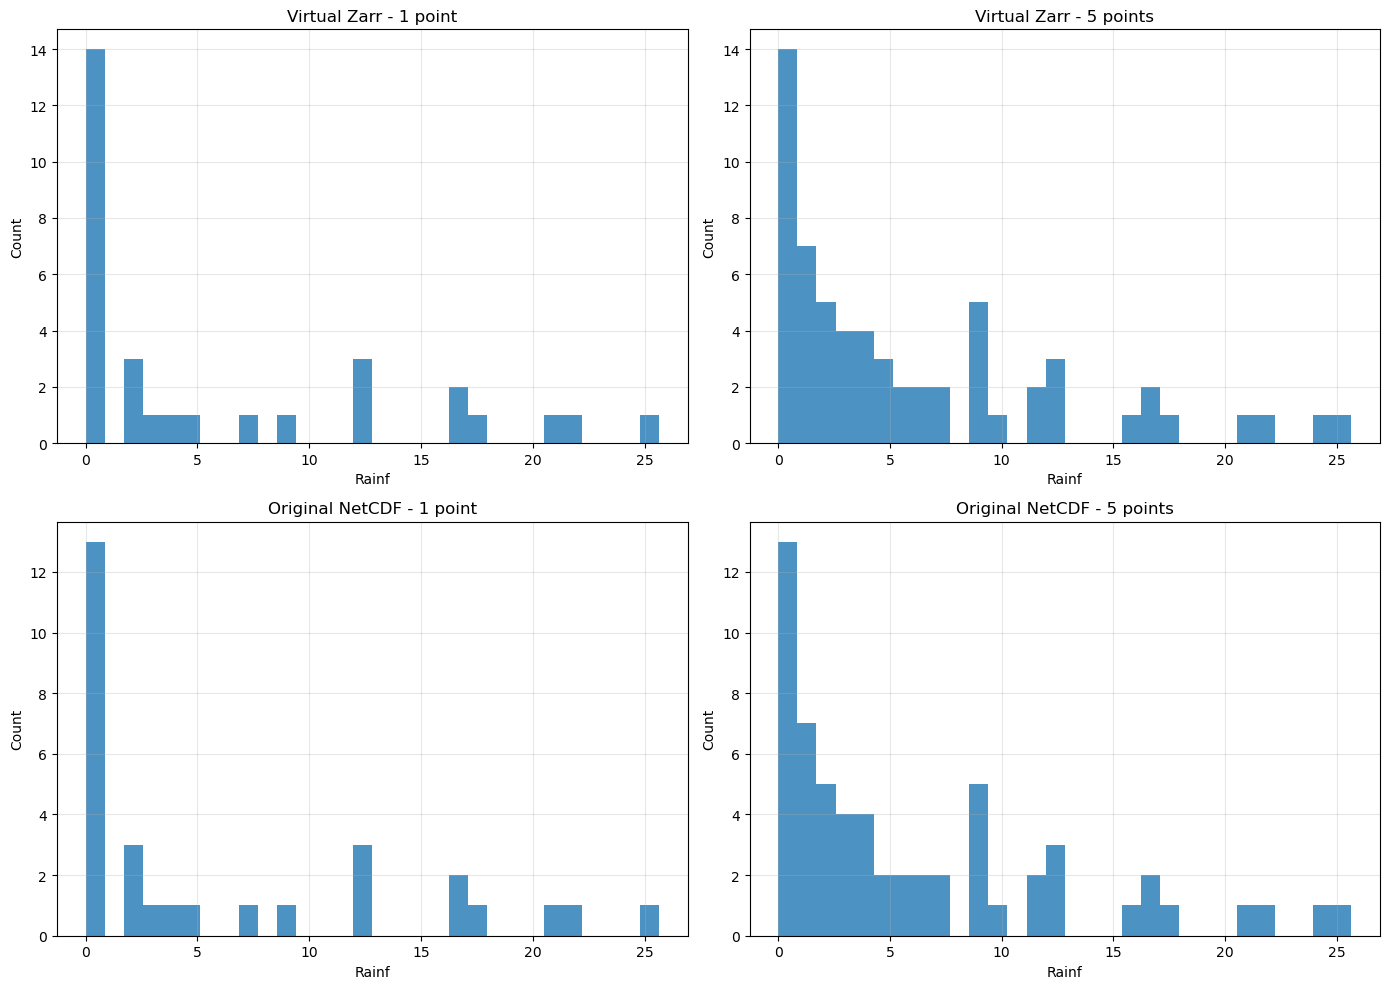

In [35]:
loaded_outputs = {}
loaded_outputs.update(loaded_outputs_vz)
loaded_outputs.update(loaded_outputs_nc)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_order = [
    ("Virtual Zarr", "1 point"),
    ("Virtual Zarr", "5 points"),
    ("Original NetCDF", "1 point"),
    ("Original NetCDF", "5 points"),
]

for ax, key in zip(axes, plot_order):
    arr = loaded_outputs[key].values.ravel()
    arr = arr[np.isfinite(arr)]

    ax.hist(arr, bins=30, alpha=0.8)
    ax.set_title(f"{key[0]} - {key[1]}")
    ax.set_xlabel(variable_name)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Example timeseries

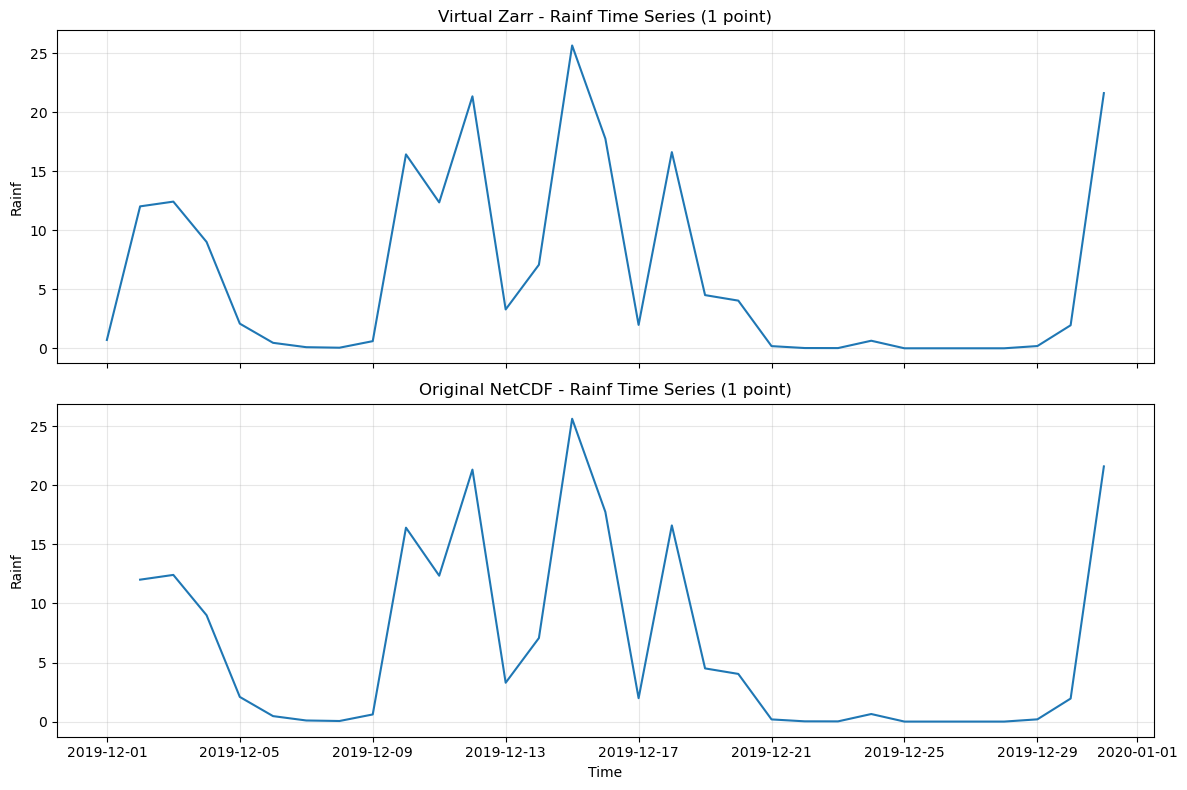

In [36]:
example_vz = loaded_outputs_vz[("Virtual Zarr", "1 point")].to_pandas()
example_nc = loaded_outputs_nc[("Original NetCDF", "1 point")].to_pandas()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(example_vz.index, example_vz.values)
axes[0].set_title("Virtual Zarr - Rainf Time Series (1 point)")
axes[0].set_ylabel(variable_name)
axes[0].grid(True, alpha=0.3)

axes[1].plot(example_nc.index, example_nc.values)
axes[1].set_title("Original NetCDF - Rainf Time Series (1 point)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(variable_name)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Notes

### What is included in the benchmark?
This notebook includes:
- dataset access / discovery time
- dataset open time
- point selection time
- data load time
- end-to-end total time

### Why can Virtual Zarr and NetCDF differ?
Differences may come from:
- multi-file metadata aggregation for NetCDF
- remote file access overhead on S3
- different chunk layouts
- indexed access behavior in Virtual Zarr
- caching differences between formats

### Interpretation
- **Query-only time** helps compare extraction speed once the dataset is ready
- **End-to-end time** is better for real workflow cost
